Manuel Griseri, Daniel Badaire, UEVE, M2QF

<h1 style="text-align: center;">Graphical Models in Finance</h1>

In [3]:
import numpy as np
import pandas as pd
from sklearn.covariance import GraphicalLasso, GraphicalLassoCV
from sklearn.preprocessing import StandardScaler
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from sklearn.linear_model import LinearRegression
from pgmpy.estimators import PC, ExpertKnowledge
import seaborn as sns
from scipy import stats
from pgmpy.models import BayesianNetwork, DynamicBayesianNetwork
from pgmpy.factors.continuous import LinearGaussianCPD
from pgmpy.inference import VariableElimination
from networkx.drawing.nx_agraph import graphviz_layout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import jarque_bera

## 1. Exploratory Data Analysis

In [5]:
# Global configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
print("✓ Imports done")

✓ Imports done


In [6]:
# Data loading
market_df = pd.read_csv("market.csv")
map_df = pd.read_csv("map.csv")

In [7]:
# Exploratory data analysis
def run_exploratory_data_analysis(market_df: pd.DataFrame, map_df: pd.DataFrame):
    """Run EDA steps."""

    # Show basic info
    print(f"Shape: {market_df.shape}")
    print(f"Period: {market_df.index[0]} to {market_df.index[-1]}")
    print(f"\nVariables: {market_df.columns.tolist()}")

    # Missing values
    print("\nTotal number of missing values:", market_df.isna().sum().sum())

    # Constant columns
    print("Columns with 0 variance:", market_df.columns[market_df.var() == 0].tolist())
    print("\n")
    
    # Descriptive statistic
    print(market_df.describe())

    # Known columns
    asset_col = "asset"
    sector_col = "sector"

    assets = [c for c in market_df.columns if c not in ["MKT"] and not c.startswith("SEC")]

    print("\nNumber of assets:", len(assets))
    print("Non mapped assets:", set(assets) - set(map_df[asset_col]))
    print("Non unique mapping:", map_df[asset_col].duplicated().any())
    print("\n")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    market_df["MKT"].plot(ax=axes[0], title="Returns of global market (MKT)")
    axes[0].set_ylabel("Return")

    market_df[[f"SEC{i:02d}" for i in range(1, 4)]].plot(
        ax=axes[1], title="Returns of 3 sectors"
    )
    axes[1].set_ylabel("Return")

    plt.tight_layout()
    plt.show()
    print("\n")

    sectors = [f"SEC{i:02d}" for i in range(1, 11)]
    corr_matrix = market_df[["MKT"] + sectors].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation market-sectors")
    plt.tight_layout()
    # plt.savefig("Cormat.png", dpi=300, bbox_inches='tight')
    plt.show()

    selected_assets = (
        map_df
        .groupby("sector")
        .first()["asset"]
        .values
    )

    print("\nTested assets:", selected_assets)
    print("\n")

    jb_results = []

    for asset in selected_assets:
        stat, pvalue = jarque_bera(market_df[asset])
        jb_results.append((asset, stat, pvalue))

    jb_df = pd.DataFrame(jb_results, columns=["Asset", "JB_stat", "p_value"])
    print(jb_df)

Shape: (1000, 111)
Period: 0 to 999

Variables: ['MKT', 'SEC01', 'SEC02', 'SEC03', 'SEC04', 'SEC05', 'SEC06', 'SEC07', 'SEC08', 'SEC09', 'SEC10', 'A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A007', 'A008', 'A009', 'A010', 'A011', 'A012', 'A013', 'A014', 'A015', 'A016', 'A017', 'A018', 'A019', 'A020', 'A021', 'A022', 'A023', 'A024', 'A025', 'A026', 'A027', 'A028', 'A029', 'A030', 'A031', 'A032', 'A033', 'A034', 'A035', 'A036', 'A037', 'A038', 'A039', 'A040', 'A041', 'A042', 'A043', 'A044', 'A045', 'A046', 'A047', 'A048', 'A049', 'A050', 'A051', 'A052', 'A053', 'A054', 'A055', 'A056', 'A057', 'A058', 'A059', 'A060', 'A061', 'A062', 'A063', 'A064', 'A065', 'A066', 'A067', 'A068', 'A069', 'A070', 'A071', 'A072', 'A073', 'A074', 'A075', 'A076', 'A077', 'A078', 'A079', 'A080', 'A081', 'A082', 'A083', 'A084', 'A085', 'A086', 'A087', 'A088', 'A089', 'A090', 'A091', 'A092', 'A093', 'A094', 'A095', 'A096', 'A097', 'A098', 'A099', 'A100']

Total number of missing values: 0
Columns with 0 vari

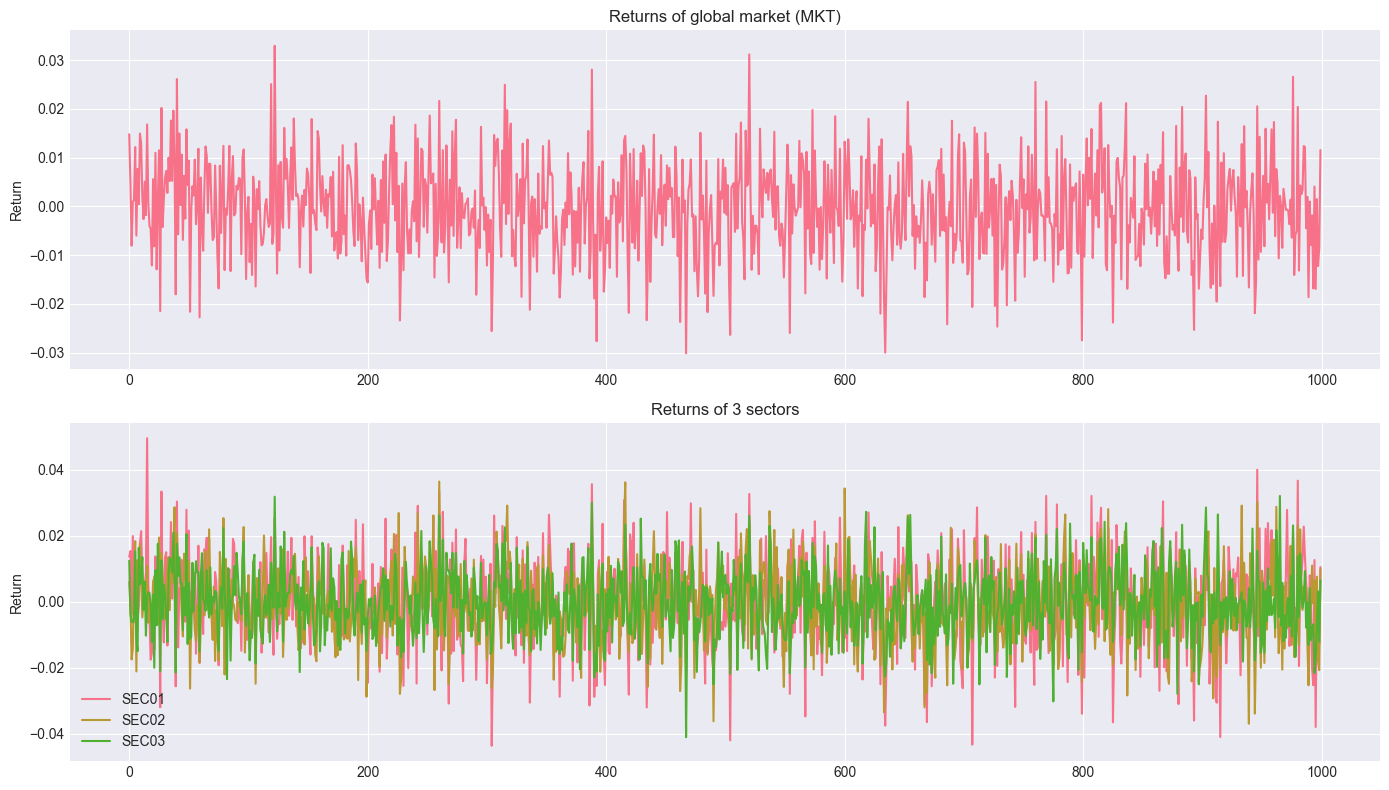

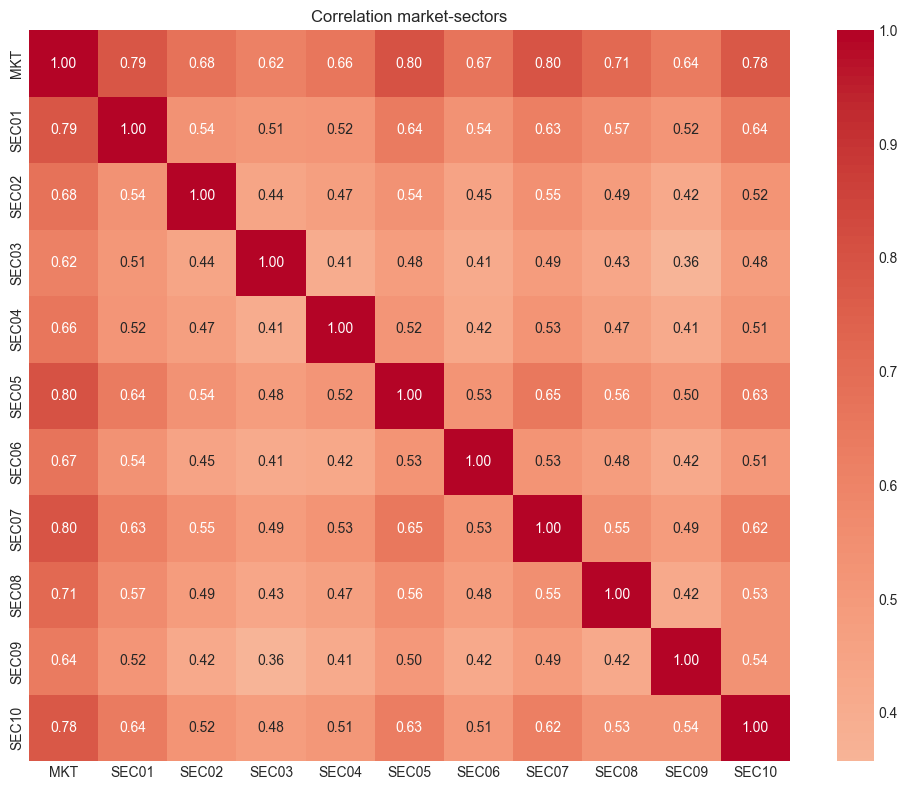


Tested assets: ['A001' 'A011' 'A021' 'A031' 'A041' 'A051' 'A061' 'A071' 'A081' 'A091']


  Asset    JB_stat   p_value
0  A001   1.508404  0.470386
1  A011   0.188509  0.910051
2  A021   3.133737  0.208698
3  A031  13.611859  0.001107
4  A041   2.945212  0.229327
5  A051   2.120602  0.346352
6  A061   0.731573  0.693651
7  A071   0.252636  0.881335
8  A081   0.636893  0.727278
9  A091   2.756301  0.252044


In [8]:
# Main execution
if __name__ == "__main__":
    run_exploratory_data_analysis(market_df, map_df)

## 2. Bayesian Network

### 2.1. Data utilities

In [11]:
def time_split_df(df: pd.DataFrame, train_ratio: float = 0.7) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Time-based split (no shuffle)."""
    cut = int(np.floor(train_ratio * len(df)))
    train = df.iloc[:cut].copy()
    test = df.iloc[cut:].copy()
    return train, test
    
def infer_variables(df: pd.DataFrame, n_sectors: int = 10) -> Tuple[str, List[str], List[str]]:
    """Infer variable names MKT, sectors SEC01..SEC10, assets = remaining columns."""
    mkt = "MKT"
    sectors = [f"SEC{i:02d}" for i in range(1, n_sectors + 1)]
    assets = [c for c in df.columns if c not in [mkt] + sectors]
    return mkt, sectors, assets

### 2.2. Structure learning (PC)

In [13]:
class PCConfig:
    variant: str = "stable"
    ci_test: str = "pearsonr"
    max_cond_vars: int = 3
    significance_level: float = 0.01
    return_type: str = "pdag"

def build_expert_knowledge(mkt: str, sectors: List[str], assets: List[str]) -> ExpertKnowledge:
    """
    Enforce the tier order: MKT -> SECTOR -> ASSET.
    In pgmpy, temporal_order can be used to constrain allowed directions.
    """
    temporal_order = [[mkt], sectors, assets]
    return ExpertKnowledge(temporal_order=temporal_order)

def fit_pc_structure(
    train_df: pd.DataFrame,
    expert_knowledge: Optional[ExpertKnowledge],
    config: PCConfig,
    enforce_expert_knowledge: bool = True
):
    """Fit PC structure learner on training data."""
    pc = PC(train_df)
    model = pc.estimate(
        variant=config.variant,
        ci_test=config.ci_test,
        max_cond_vars=config.max_cond_vars,
        significance_level=config.significance_level,
        expert_knowledge=expert_knowledge,
        enforce_expert_knowledge=enforce_expert_knowledge,
        return_type=config.return_type
    )
    return model

### 2.3. Reporting / diagnostics

In [15]:
def edge_type(u: str, v: str, mkt: str, sectors_set: set, assets_set: set) -> str:
    nodes = {u, v}
    if mkt in nodes:
        other = (nodes - {mkt}).pop()
        if other in sectors_set:
            return "MKT–SEC"
        if other in assets_set:
            return "MKT–Asset"
        return "MKT–Other"
    if u in sectors_set and v in sectors_set:
        return "SEC–SEC"
    if (u in sectors_set and v in assets_set) or (v in sectors_set and u in assets_set):
        return "SEC–Asset"
    if u in assets_set and v in assets_set:
        return "Asset–Asset"
    return "Other"

def summarize_edges(edges: List[Tuple[str, str]], mkt: str, sectors: List[str], assets: List[str]) -> pd.Series:
    sectors_set = set(sectors)
    assets_set = set(assets)
    counts = pd.Series([edge_type(u, v, mkt, sectors_set, assets_set) for (u, v) in edges]).value_counts()
    return counts

### 2.4. Post-processing: PDAG -> DAG edges

In [17]:
@dataclass
class DAGPostprocessConfig:
    remove_mkt_asset_edges: bool = True
    # If True, orient edges according to tier order (MKT<SEC<Asset)
    orient_by_tiers: bool = True
    # If True, orient within same tier deterministically to avoid cycles.
    # (Note: this is a heuristic; not "learned" by PC.)
    force_total_order_within_tier: bool = True

def tier_of(node: str, mkt: str, sectors_set: set, assets_set: set) -> int:
    if node == mkt:
        return 0
    if node in sectors_set:
        return 1
    if node in assets_set:
        return 2
    return 99

def orient_edge_by_rules(
    u: str, v: str, mkt: str, sectors_set: set, assets_set: set,
    force_total_order_within_tier: bool = True
) -> Tuple[str, str]:
    tu = tier_of(u, mkt, sectors_set, assets_set)
    tv = tier_of(v, mkt, sectors_set, assets_set)

    # Different tiers: direct low->high
    if tu < tv:
        return (u, v)
    if tv < tu:
        return (v, u)

    # Same tier: heuristic orientation to ensure DAG
    if force_total_order_within_tier:
        return (min(u, v), max(u, v))
    else:
        # Keep original orientation-less relationship by choosing an arbitrary but stable rule
        return (u, v)

def pdag_to_dag_edges(
    pdag_edges: List[Tuple[str, str]],
    mkt: str, sectors: List[str], assets: List[str],
    cfg: DAGPostprocessConfig
) -> List[Tuple[str, str]]:
    sectors_set = set(sectors)
    assets_set = set(assets)

    # Optional removal of MKT-Asset edges (strict MKT->SEC->Asset)
    filtered = pdag_edges
    if cfg.remove_mkt_asset_edges:
        filtered = [
            (u, v) for (u, v) in filtered
            if not ((u == mkt and v in assets_set) or (v == mkt and u in assets_set))
        ]

    # Orient edges
    if cfg.orient_by_tiers:
        dag_edges = [
            orient_edge_by_rules(u, v, mkt, sectors_set, assets_set, cfg.force_total_order_within_tier)
            for (u, v) in filtered
        ]
    else:
        dag_edges = filtered.copy()

    # Deduplicate preserving order
    dag_edges = list(dict.fromkeys(dag_edges))
    return dag_edges

### 2.5. Parameter learning: Linear Gaussian CPDs

In [19]:
@dataclass
class NodeModel:
    kind: str  # "root" or "linreg"
    mu: Optional[float] = None
    parents: Optional[List[str]] = None
    reg: Optional[LinearRegression] = None
    sigma: Optional[float] = None

def build_parents_dict(nodes: List[str], dag_edges: List[Tuple[str, str]]) -> Dict[str, List[str]]:
    parents = {n: [] for n in nodes}
    for u, v in dag_edges:
        if v in parents:
            parents[v].append(u)
    return parents

def fit_linear_gaussian_bn(train_df: pd.DataFrame, nodes: List[str], parents: Dict[str, List[str]]) -> Dict[str, NodeModel]:
    """
    Fit root nodes with (mu, sigma),
    non-root nodes with linear regression on parents + residual sigma.
    """
    fitted: Dict[str, NodeModel] = {}
    for node in nodes:
        pa = parents.get(node, [])
        if len(pa) == 0:
            mu = float(train_df[node].mean())
            sigma = float(train_df[node].std(ddof=1))
            fitted[node] = NodeModel(kind="root", mu=mu, parents=[], reg=None, sigma=sigma)
        else:
            X = train_df[pa].to_numpy()
            y = train_df[node].to_numpy()
            reg = LinearRegression().fit(X, y)
            resid = y - reg.predict(X)
            sigma = float(resid.std(ddof=1))
            fitted[node] = NodeModel(kind="linreg", mu=None, parents=pa, reg=reg, sigma=sigma)
    return fitted

def predict_node(node: str, fitted: Dict[str, NodeModel], df: pd.DataFrame) -> np.ndarray:
    spec = fitted[node]
    if spec.kind == "root":
        return np.full(len(df), spec.mu, dtype=float)
    else:
        X = df[spec.parents].to_numpy()
        return spec.reg.predict(X)

### 2.6. Evaluation utilities

In [21]:
def evaluate_assets(
    fitted: Dict[str, NodeModel],
    test_df: pd.DataFrame,
    assets_to_predict: List[str]
) -> pd.DataFrame:
    rows = []
    for a in assets_to_predict:
        y_true = test_df[a].to_numpy()
        y_pred = predict_node(a, fitted, test_df)

        mse = float(np.mean((y_true - y_pred) ** 2))
        corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan

        pa = fitted[a].parents if fitted[a].kind == "linreg" else []
        rows.append({"asset": a, "n_parents": len(pa), "parents": pa, "mse": mse, "corr": corr})
    return pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)

### 2.7. Visualization

In [23]:
def visualize_bn(dag_edges: List[Tuple[str, str]]) -> None:
    G = nx.DiGraph(dag_edges)
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    node_colors = []
    for node in G.nodes():
        if node == "MKT":
            node_colors.append("red")
        elif node.startswith("SEC"):
            node_colors.append("blue")
        else:
            node_colors.append("green")

    nx.draw(
        G, pos, with_labels=True,
        node_color=node_colors, node_size=900, font_size=7,
        arrows=True, arrowsize=10, edge_color="gray", alpha=0.7
    )
    plt.tight_layout()
    # plt.savefig("Dirnet.png", dpi=300, bbox_inches='tight')
    plt.show()

### 2.8. End-to-end pipeline

In [25]:
@dataclass
class BNResults:
    pdag_model: object
    pdag_edges: List[Tuple[str, str]]
    pdag_edge_summary: pd.Series

    dag_edges: List[Tuple[str, str]]
    dag_edge_summary: pd.Series

    nodes: List[str]
    parents: Dict[str, List[str]]
    fitted: Dict[str, NodeModel]

    perf: Optional[pd.DataFrame] = None

def run_part1_bayesian_network(
    market_df: pd.DataFrame,
    train_ratio: float = 0.7,
    pc_config: PCConfig = PCConfig(),
    dag_cfg: DAGPostprocessConfig = DAGPostprocessConfig(),
    assets_to_predict: Optional[List[str]] = None,
    enforce_expert_knowledge: bool = True
) -> BNResults:
    # Data split
    train_df, test_df = time_split_df(market_df, train_ratio=train_ratio)

    # Variables
    mkt, sectors, assets = infer_variables(train_df)
    nodes = [mkt] + sectors + assets

    # Expert knowledge
    ek = build_expert_knowledge(mkt, sectors, assets)

    # Structure learning (PDAG)
    pdag_model = fit_pc_structure(train_df, ek, pc_config, enforce_expert_knowledge=enforce_expert_knowledge)
    pdag_edges = list(pdag_model.edges())
    pdag_summary = summarize_edges(pdag_edges, mkt, sectors, assets)

    # PDAG -> DAG
    dag_edges = pdag_to_dag_edges(pdag_edges, mkt, sectors, assets, dag_cfg)
    dag_summary = summarize_edges(dag_edges, mkt, sectors, assets)

    # Parameter learning
    parents = build_parents_dict(nodes, dag_edges)
    fitted = fit_linear_gaussian_bn(train_df, nodes, parents)

    # Evaluation
    perf = None
    if assets_to_predict is not None and len(assets_to_predict) > 0:
        perf = evaluate_assets(fitted, test_df, assets_to_predict)

    return BNResults(
        pdag_model=pdag_model,
        pdag_edges=pdag_edges,
        pdag_edge_summary=pdag_summary,
        dag_edges=dag_edges,
        dag_edge_summary=dag_summary,
        nodes=nodes,
        parents=parents,
        fitted=fitted,
        perf=perf
    )

### 2.9. Main

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'MKT': 'N', 'SEC01': 'N', 'SEC02': 'N', 'SEC03': 'N', 'SEC04': 'N', 'SEC05': 'N', 'SEC06': 'N', 'SEC07': 'N', 'SEC08': 'N', 'SEC09': 'N', 'SEC10': 'N', 'A001': 'N', 'A002': 'N', 'A003': 'N', 'A004': 'N', 'A005': 'N', 'A006': 'N', 'A007': 'N', 'A008': 'N', 'A009': 'N', 'A010': 'N', 'A011': 'N', 'A012': 'N', 'A013': 'N', 'A014': 'N', 'A015': 'N', 'A016': 'N', 'A017': 'N', 'A018': 'N', 'A019': 'N', 'A020': 'N', 'A021': 'N', 'A022': 'N', 'A023': 'N', 'A024': 'N', 'A025': 'N', 'A026': 'N', 'A027': 'N', 'A028': 'N', 'A029': 'N', 'A030': 'N', 'A031': 'N', 'A032': 'N', 'A033': 'N', 'A034': 'N', 'A035': 'N', 'A036': 'N', 'A037': 'N', 'A038': 'N', 'A039': 'N', 'A040': 'N', 'A041': 'N', 'A042': 'N', 'A043': 'N', 'A044': 'N', 'A045': 'N', 'A046': 'N', 'A047': 'N', 'A048': 'N', 'A049': 'N', 'A050': 'N', 'A051': 'N', 'A052': 'N', 'A053': 'N', 'A054': 'N', 'A055': 'N', 'A056': 'N', 'A057': 'N', '

  0%|          | 0/5 [00:00<?, ?it/s]

INFO:pgmpy:Reached maximum number of allowed conditional variables. Exiting


PDAG edge breakdown:
SEC–Asset      101
MKT–Asset      100
Asset–Asset     50
MKT–SEC         10
Name: count, dtype: int64

DAG edge breakdown (after post-processing):
SEC–Asset      101
Asset–Asset     43
MKT–SEC         10
Name: count, dtype: int64

Prediction performance:
  asset  n_parents              parents       mse      corr
0  A001          1              [SEC01]  0.000049  0.867452
1  A100          2        [SEC10, A092]  0.000091  0.663502
2  A082          1              [SEC09]  0.000107  0.754104
3  A090          2        [SEC09, A082]  0.000108  0.750454
4  A050          3  [SEC05, A041, A042]  0.000111  0.673296


C:\Users\Manuel\AppData\Local\Temp\ipykernel_12032\1546319709.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


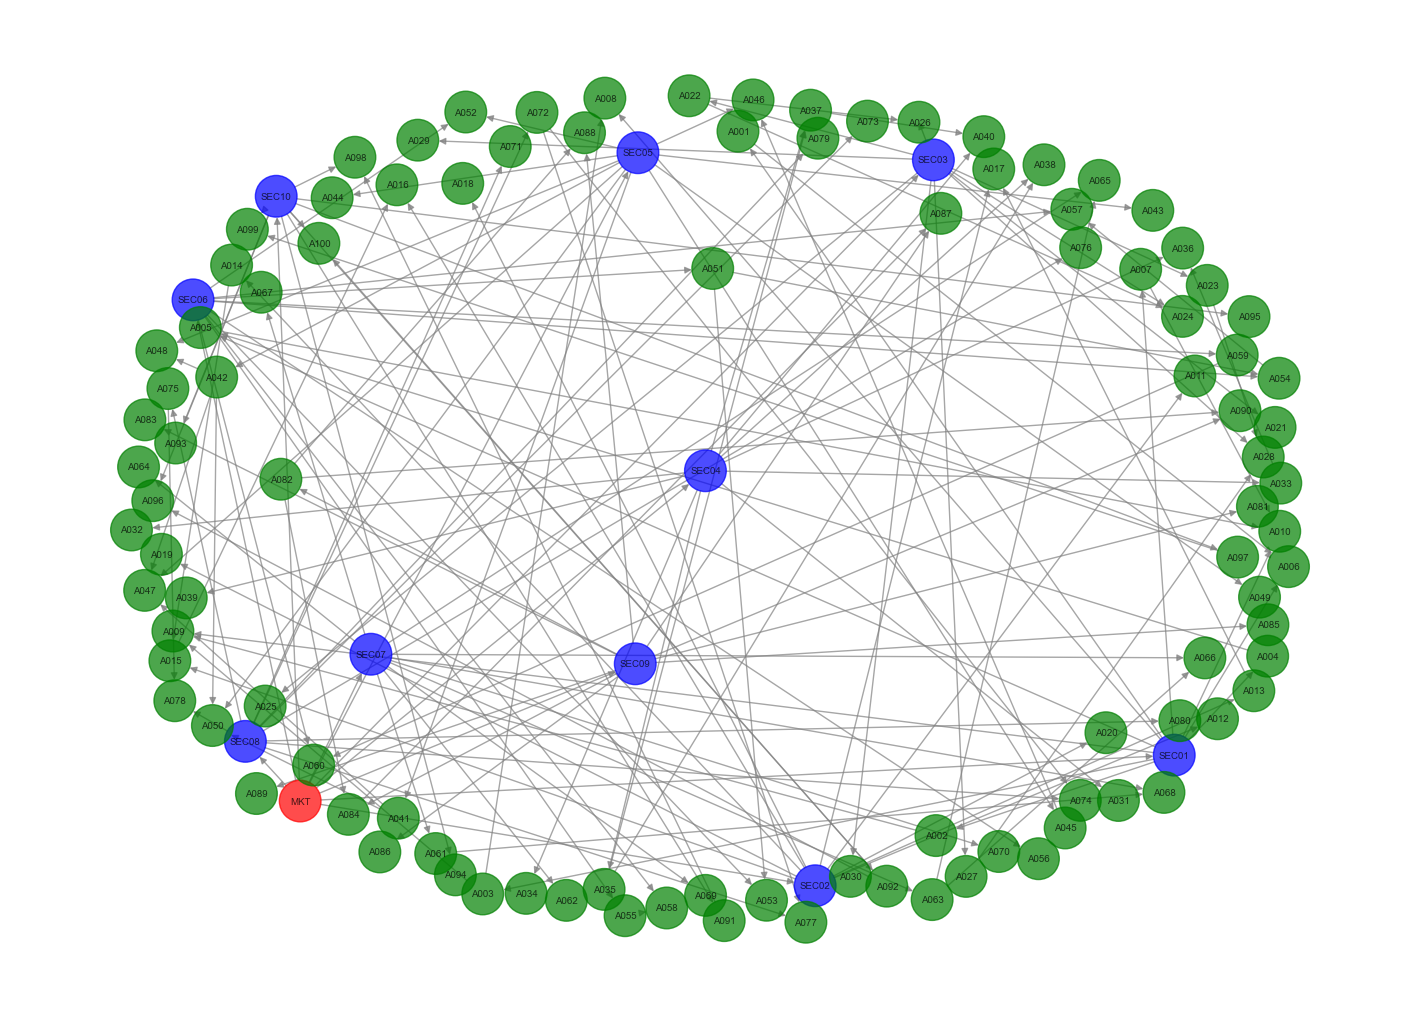

In [27]:
if __name__ == "__main__":
    assets_to_predict = ["A001", "A050", "A082", "A090", "A100"]

    res_bn = run_part1_bayesian_network(
        market_df=market_df,
        train_ratio=0.7,
        assets_to_predict=assets_to_predict,
        enforce_expert_knowledge=True,
        dag_cfg=DAGPostprocessConfig(
            remove_mkt_asset_edges=True,
            orient_by_tiers=True,
            force_total_order_within_tier=True
        )
    )

    print("PDAG edge breakdown:")
    print(res_bn.pdag_edge_summary)

    print("\nDAG edge breakdown (after post-processing):")
    print(res_bn.dag_edge_summary)

    if res_bn.perf is not None:
        print("\nPrediction performance:")
        print(res_bn.perf)

    visualize_bn(res_bn.dag_edges)

## 3. Markov Network

### 3.1. Data utilities

In [30]:
def load_assets_only(market_csv_path: str, map_csv_path: str):
    """
    Load the dataset and return:
      - returns matrix X (T x P) for assets A001..A100 only
      - asset column names
      - a dict asset -> sector (e.g., "A001" -> "SEC03")
    """
    df = pd.read_csv(market_csv_path)

    # Asset columns are A001...A100
    asset_cols = [c for c in df.columns if c.startswith("A") and len(c) == 4 and c[1:].isdigit()]
    asset_cols = sorted(asset_cols)

    if len(asset_cols) != 100:
        raise ValueError(f"Expected 100 asset columns A001..A100, found {len(asset_cols)}.")

    X = df[asset_cols].to_numpy(dtype=float)

    # map.csv provides asset-to-sector mapping (one sector per asset)
    mapping = pd.read_csv(map_csv_path)

    # Make this robust to common column name variants
    cols_lower = {c.lower(): c for c in mapping.columns}
    if "asset" in cols_lower and "sector" in cols_lower:
        asset_col = cols_lower["asset"]
        sector_col = cols_lower["sector"]
    else:
        # Fall back: first two columns are (asset, sector)
        asset_col = mapping.columns[0]
        sector_col = mapping.columns[1]

    asset_to_sector = dict(zip(mapping[asset_col].astype(str), mapping[sector_col].astype(str)))

    # Safety: ensure all assets have mapping
    missing = [a for a in asset_cols if a not in asset_to_sector]
    if missing:
        raise ValueError(f"Missing sector mapping for assets: {missing[:10]} (showing up to 10)")

    return X, asset_cols, asset_to_sector    

# Utilisation time_split(X: np.ndarray, train_ratio: float = 0.7)
def time_split(X: np.ndarray, train_ratio: float = 0.7):
    """
    Time-based split (no shuffling).
    """
    T = X.shape[0]
    cut = int(np.floor(train_ratio * T))
    X_train = X[:cut]
    X_test = X[cut:]
    return X_train, X_test

def standardize_train_test(X_train: np.ndarray, X_test: np.ndarray):
    """
    Standardize using train mean/std only (prevents leakage).
    Graphical Lasso is sensitive to scale.
    """
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)
    return Xtr, Xte, scaler

### 3.2. Structure learning: Graphical Lasso

In [32]:
def fit_graphical_lasso_cv(X_train: np.ndarray, alphas=None, cv_folds: int = 5):
    """
    Structure learning with GraphicalLassoCV (cross-validated alpha).
    Returns fitted model.
    """
    if alphas is None:
        # A reasonable grid
        alphas = np.logspace(-3, 0, 30)

    model = GraphicalLassoCV(alphas=alphas, cv=cv_folds)
    model.fit(X_train)
    return model

def fit_graphical_lasso_bic(X_train: np.ndarray, alphas=None, max_iter: int = 2000, tol: float = 1e-4):
    """
    Optional: choose alpha by minimizing BIC for Graphical Lasso.
    BIC = -2 * logLik + k * log(N)
      - logLik: Gaussian log-likelihood evaluated at estimated covariance
      - k: number of free parameters (nonzero entries in precision; symmetric)
      - N: number of samples

    Returns: (best_model, bic_table_dataframe)
    """
    if alphas is None:
        alphas = np.logspace(-3, 0, 30)

    N, P = X_train.shape
    bics = []
    models = []

    for a in alphas:
        m = GraphicalLasso(alpha=a, max_iter=max_iter, tol=tol)
        m.fit(X_train)

        # Gaussian log-likelihood under estimated covariance:
        # sklearn provides score() = per-sample log-likelihood
        loglik = m.score(X_train) * N  # total log-likelihood

        # Count effective parameters in precision matrix (symmetric):
        # Diagonal always counts (P).
        # Off-diagonal: count nonzeros in upper triangle.
        Theta = m.precision_
        off_nz = np.sum(np.abs(np.triu(Theta, k=1)) > 1e-8)
        k_params = P + off_nz  # diag + unique off-diagonal

        bic = -2.0 * loglik + k_params * np.log(N)
        bics.append(bic)
        models.append(m)

    bic_df = pd.DataFrame({"alpha": alphas, "bic": bics}).sort_values("bic").reset_index(drop=True)
    best_idx = int(np.argmin(bics))
    return models[best_idx], bic_df

### 3.3. Graph reporting: edges, sparsity, sectors

In [34]:
def precision_to_graph(precision: np.ndarray, nodes: list[str], threshold: float = 1e-8):
    """
    Build an undirected graph where an edge (i,j) exists if precision[i,j] != 0.
    """
    P = precision.shape[0]
    G = nx.Graph()
    G.add_nodes_from(nodes)

    for i in range(P):
        for j in range(i + 1, P):
            if abs(precision[i, j]) > threshold:
                # Weight can be useful for visualization; store absolute partial correlation proxy
                G.add_edge(nodes[i], nodes[j], weight=float(abs(precision[i, j])))

    return G

def graph_stats(G: nx.Graph, asset_to_sector: dict[str, str]):
    """
    Compute:
      - sparsity level (edge density)
      - number of connected components and sizes
      - within-sector edge ratio
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    possible = n * (n - 1) / 2
    density = m / possible if possible > 0 else 0.0
    sparsity = 1.0 - density

    comps = list(nx.connected_components(G))
    comp_sizes = sorted([len(c) for c in comps], reverse=True)

    within = 0
    for u, v in G.edges():
        if asset_to_sector.get(u) == asset_to_sector.get(v):
            within += 1
    within_ratio = within / m if m > 0 else np.nan

    return {
        "n_nodes": n,
        "n_edges": m,
        "density": density,
        "sparsity": sparsity,
        "n_components": len(comps),
        "component_sizes_desc": comp_sizes[:10],  # show largest 10
        "within_sector_edge_ratio": within_ratio,
    }

### 3.4. Test evaluation

In [36]:
def evaluate_on_test(model, X_test: np.ndarray):
    """
    Evaluate log-likelihood on the test set.
    model.score(X) = average log-likelihood per sample.
    """
    avg_ll = model.score(X_test)
    total_ll = avg_ll * X_test.shape[0]
    return {"avg_loglik": avg_ll, "total_loglik": total_ll}

### 3.5. Inference in a Gaussian graphical model

In [38]:
# Compute P(B | A=a) for a joint Gaussian
def gaussian_conditional(
    mu: np.ndarray,
    Sigma: np.ndarray,
    idx_A: List[int],
    a_values: np.ndarray
) -> Tuple[List[int], np.ndarray, np.ndarray]:
    """
    For a joint Gaussian X ~ N(mu, Sigma), partition indices into:
      - A: observed indices (idx_A)
      - B: remaining indices

    Returns parameters of:
      X_B | X_A=a ~ N(mu_cond, Sigma_cond)
    """
    P = mu.shape[0]
    idx_A = list(idx_A)
    idx_B = [i for i in range(P) if i not in idx_A]

    mu_A = mu[idx_A]
    mu_B = mu[idx_B]

    Sigma_AA = Sigma[np.ix_(idx_A, idx_A)]
    Sigma_BB = Sigma[np.ix_(idx_B, idx_B)]
    Sigma_BA = Sigma[np.ix_(idx_B, idx_A)]
    Sigma_AB = Sigma[np.ix_(idx_A, idx_B)]

    # Conditional mean and covariance
    Sigma_AA_inv = np.linalg.inv(Sigma_AA)
    mu_cond = mu_B + Sigma_BA @ Sigma_AA_inv @ (a_values - mu_A)
    Sigma_cond = Sigma_BB - Sigma_BA @ Sigma_AA_inv @ Sigma_AB

    return idx_B, mu_cond, Sigma_cond

def predict_conditional_mean_over_time(
    covariance_std: np.ndarray,
    X_test_std: np.ndarray,
    assets: List[str],
    target_asset: str,
    observed_assets: List[str]
) -> np.ndarray:
    """
    Predict E[target | observed] for each time in the test set.

    Notes:
    - This operates in standardized space (because covariance_std comes from GraphicalLasso fitted on standardized data).
    - Returned predictions are in standardized units.
    """
    asset_to_idx = {a: i for i, a in enumerate(assets)}

    if target_asset not in asset_to_idx:
        raise ValueError(f"Unknown target asset: {target_asset}")

    for oa in observed_assets:
        if oa not in asset_to_idx:
            raise ValueError(f"Unknown observed asset: {oa}")

    idx_target = asset_to_idx[target_asset]
    idx_A = [asset_to_idx[a] for a in observed_assets]

    if idx_target in idx_A:
        raise ValueError("Target asset cannot be among the observed assets.")

    P = len(assets)
    mu = np.zeros(P, dtype=float)

    y_pred_std = np.empty(X_test_std.shape[0], dtype=float)

    for t in range(X_test_std.shape[0]):
        a_values = X_test_std[t, idx_A]

        idx_B, mu_cond, _ = gaussian_conditional(mu, covariance_std, idx_A, a_values)

        # Find the target inside B and read its conditional mean
        pos_in_B = idx_B.index(idx_target)
        y_pred_std[t] = float(mu_cond[pos_in_B])

    return y_pred_std

def conditional_prediction_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray
) -> Dict[str, float]:
    """
    Compute MSE and Pearson correlation between true and predicted series.
    """
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan
    return {"mse": mse, "corr": corr}

def evaluate_conditional_inference_on_test(
    covariance_std: np.ndarray,
    X_test_std: np.ndarray,
    X_test_raw: np.ndarray,
    assets: List[str],
    scaler,
    target_asset: str,
    observed_assets: List[str]
) -> Dict[str, object]:
    """
    End-to-end evaluation:
      - Predict conditional mean at each test time (standardized space)
      - Convert prediction back to raw scale using the scaler
      - Compute MSE and correlation against raw test target
    """
    asset_to_idx = {a: i for i, a in enumerate(assets)}
    idx_target = asset_to_idx[target_asset]

    # Predict in standardized space
    y_pred_std = predict_conditional_mean_over_time(
        covariance_std=covariance_std,
        X_test_std=X_test_std,
        assets=assets,
        target_asset=target_asset,
        observed_assets=observed_assets
    )

    # Inverse standardization for the target dimension only:
    # raw = std * scale_ + mean_
    y_pred_raw = y_pred_std * scaler.scale_[idx_target] + scaler.mean_[idx_target]

    # True raw values
    y_true_raw = X_test_raw[:, idx_target]

    metrics = conditional_prediction_metrics(y_true_raw, y_pred_raw)

    return {
        "target": target_asset,
        "observed": observed_assets,
        "mse": metrics["mse"],
        "corr": metrics["corr"],
        "y_true": y_true_raw,
        "y_pred": y_pred_raw
    }

### 3.6. End-to-end pipeline

In [40]:
def run_part2_markov_network(
    market_csv_path: str = "market.csv",
    map_csv_path: str = "map.csv",
    train_ratio: float = 0.7,
    use_bic_selection: bool = False
):
    # Load and split
    X, assets, asset_to_sector = load_assets_only(market_csv_path, map_csv_path)
    X_train, X_test = time_split(X, train_ratio=train_ratio)

    # Standardize
    Xtr, Xte, scaler = standardize_train_test(X_train, X_test)

    # Structure learning (CV or BIC)
    if use_bic_selection:
        model, bic_table = fit_graphical_lasso_bic(Xtr)
        selected_alpha = model.alpha
    else:
        model = fit_graphical_lasso_cv(Xtr)
        bic_table = None
        selected_alpha = model.alpha_

    # Parameter learning outputs
    precision = model.precision_
    covariance = model.covariance_

    # Build graph and compute stats
    G = precision_to_graph(precision, assets)
    stats = graph_stats(G, asset_to_sector)

    # Evaluate on test set
    test_metrics = evaluate_on_test(model, Xte)

    results = {
        "selected_alpha": float(selected_alpha),
        "precision": precision,
        "covariance": covariance,
        "graph": G,
        "graph_stats": stats,
        "test_metrics": test_metrics,
        "bic_table": bic_table
    }
    return results

### 3.7. Partial correlations from precision (more interpretable)

In [42]:
def precision_to_partial_corr(precision: np.ndarray, eps: float = 1e-12):
    """
    Convert a precision matrix Theta into a partial correlation matrix.

    For i != j:
      rho_ij = -Theta_ij / sqrt(Theta_ii * Theta_jj)

    Diagonal is set to 1.
    """
    Theta = precision
    d = np.diag(Theta).copy()

    # Numerical safety: avoid division by zero
    d = np.maximum(d, eps)
    denom = np.sqrt(np.outer(d, d))

    pcorr = -Theta / denom
    np.fill_diagonal(pcorr, 1.0)
    return pcorr

def add_partial_corr_as_edge_attr(G: nx.Graph, partial_corr: np.ndarray, nodes: list[str]):
    """
    Add partial correlation (signed) as an edge attribute for each edge in G.
    """
    idx = {n: i for i, n in enumerate(nodes)}
    for u, v in G.edges():
        i, j = idx[u], idx[v]
        G.edges[u, v]["partial_corr"] = float(partial_corr[i, j])
        G.edges[u, v]["abs_partial_corr"] = float(abs(partial_corr[i, j]))
    return G

### 3.8. Sector statistics + network plots

In [44]:
def sector_edge_matrix(G: nx.Graph, asset_to_sector: dict[str, str]):
    """
    Build a sector-by-sector edge count matrix.

    Returns:
      - df_counts: square DataFrame indexed by sector, with edge counts
      - df_within_ratio: within-sector ratio per sector (within / total incident edges)
    """
    sectors = sorted({asset_to_sector[n] for n in G.nodes()})
    sec_idx = {s: k for k, s in enumerate(sectors)}
    M = np.zeros((len(sectors), len(sectors)), dtype=int)

    for u, v in G.edges():
        su = asset_to_sector[u]
        sv = asset_to_sector[v]
        i, j = sec_idx[su], sec_idx[sv]
        M[i, j] += 1
        if i != j:
            M[j, i] += 1  # keep it symmetric in counts

    df_counts = pd.DataFrame(M, index=sectors, columns=sectors)

    # Within-sector ratio per sector: within / total edges incident to that sector in the matrix
    within = np.diag(M).astype(float)
    total = M.sum(axis=1).astype(float)
    ratio = np.divide(within, total, out=np.zeros_like(within), where=(total > 0))
    df_within_ratio = pd.DataFrame({"sector": sectors, "within_sector_ratio": ratio}).set_index("sector")

    return df_counts, df_within_ratio

def plot_network(
    G: nx.Graph,
    asset_to_sector: dict[str, str],
    max_nodes: int = 100,
    seed: int = 42,
):
    """
    Plot the whole network (up to max_nodes). Colors represent sectors.
    A legend is added to map colors to sector codes and names.
    Note: we use a standard matplotlib colormap (no custom palette).
    """

    # If needed, subset to the most connected nodes for readability
    H = G.copy()
    if H.number_of_nodes() > max_nodes:
        deg = dict(H.degree())
        keep = sorted(deg.keys(), key=lambda n: deg[n], reverse=True)[:max_nodes]
        H = H.subgraph(keep).copy()

    # Readable sector names
    sector_names = {
        "SEC01": "Technology",
        "SEC02": "Financials",
        "SEC03": "Energy",
        "SEC04": "Healthcare",
        "SEC05": "Consumer Discretionary",
        "SEC06": "Consumer Staples",
        "SEC07": "Industrials",
        "SEC08": "Utilities",
        "SEC09": "Materials",
        "SEC10": "Communication Services",
    }

    # Build sector labels and indices
    sectors = sorted({asset_to_sector[n] for n in H.nodes()})
    sector_to_int = {s: i for i, s in enumerate(sectors)}
    node_values = [sector_to_int[asset_to_sector[n]] for n in H.nodes()]

    # Use the same colormap for nodes and legend
    cmap = plt.cm.get_cmap("tab10")

    # Graph layout
    pos = nx.spring_layout(H, seed=seed)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw_networkx_nodes(
        H,
        pos,
        node_size=60,
        node_color=node_values,   # numeric values
        cmap=cmap,                # explicit colormap -> consistent with legend
        vmin=0,
        vmax=max(len(sectors) - 1, 0),
        ax=ax,
    )
    nx.draw_networkx_edges(H, pos, alpha=0.35, ax=ax)

    # Build legend handles (use the same colormap mapping)
    legend_handles = []
    for sector, idx in sector_to_int.items():
        label = f"{sector} – {sector_names.get(sector, sector)}"
        color = cmap(idx % 10)
        legend_handles.append(mpatches.Patch(color=color, label=label))

    # Place legend outside the plot (no overlap)
    ax.legend(
        handles=legend_handles,
        title="Sectors",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=10,
        frameon=True,
    )

    ax.axis("off")

    # Make room on the right for the legend
    fig.tight_layout(rect=[0, 0, 0.8, 1])
    # plt.savefig("MRF.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_sector_mixing_heatmap(df_counts: pd.DataFrame, title: str = "Sector-by-sector edge counts"):
    """
    Plot a heatmap of sector mixing (edge counts between sectors).
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(df_counts.to_numpy(), aspect="auto")
    plt.xticks(range(df_counts.shape[1]), df_counts.columns, rotation=90)
    plt.yticks(range(df_counts.shape[0]), df_counts.index)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

### 3.9. Main

C:\Users\Manuel\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Selected alpha:
 0.035622478902624426

Graph stats:
 {'n_nodes': 100, 'n_edges': 1255, 'density': 0.25353535353535356, 'sparsity': 0.7464646464646465, 'n_components': 1, 'component_sizes_desc': [100], 'within_sector_edge_ratio': 0.3083665338645418}

Test metrics:
 {'avg_loglik': -119.26373975817806, 'total_loglik': -35779.121927453416}

[MRF Inference] Target: A100 | Observed: ['A092']
MSE: 0.00010432164582388698 | Corr: 0.6106708299453564

[MRF Inference] Target: A050 | Observed: ['A042', 'A047']
MSE: 0.00012843307200641129 | Corr: 0.6054227047463051

Top 10 edges by |partial corr|:
A072 A077 partial_corr= 0.4191
A022 A024 partial_corr= 0.4083
A097 A099 partial_corr= 0.3945
A005 A010 partial_corr= 0.394
A045 A046 partial_corr= 0.3923
A037 A040 partial_corr= 0.379
A013 A017 partial_corr= 0.3694
A014 A015 partial_corr= 0.3671
A001 A006 partial_corr= 0.354
A071 A080 partial_corr= 0.3495


C:\Users\Manuel\AppData\Local\Temp\ipykernel_12032\3270775412.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


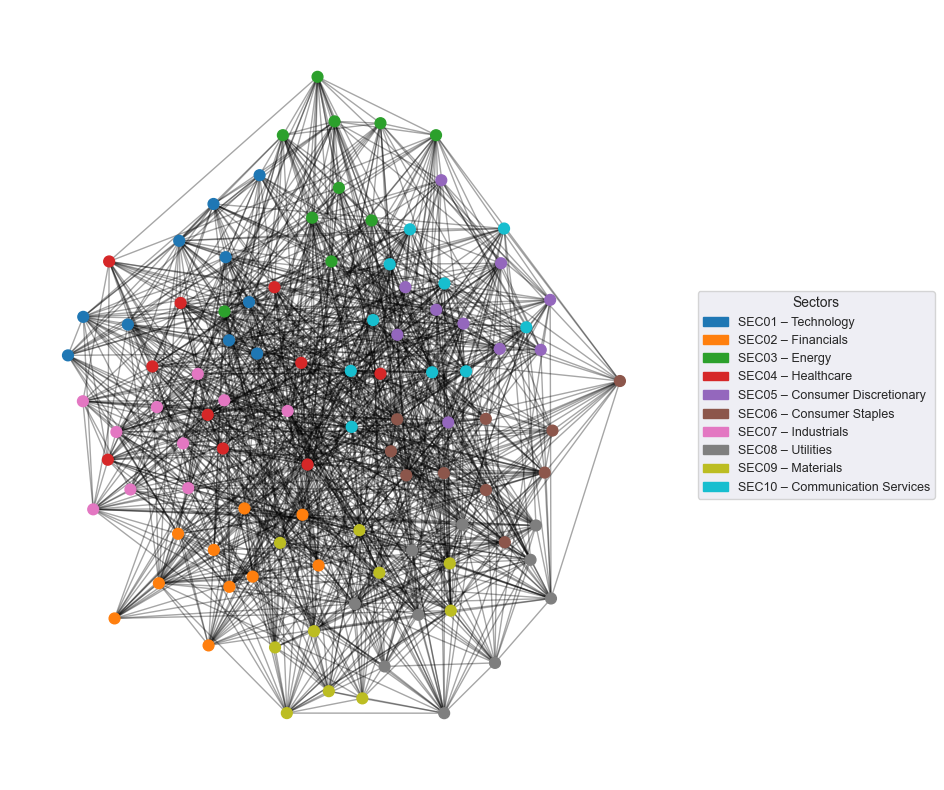


Within-sector ratio per sector (first 10):
        within_sector_ratio
sector                     
SEC01              0.177885
SEC02              0.189573
SEC03              0.189573
SEC04              0.168224
SEC05              0.198980
SEC06              0.179612
SEC07              0.200000
SEC08              0.182648
SEC09              0.190698
SEC10              0.150215


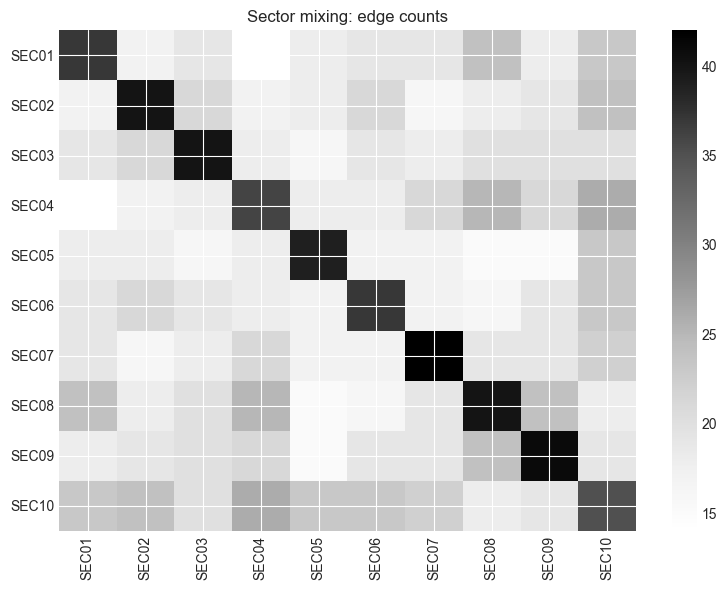

In [46]:
if __name__ == "__main__":
    res_mrf = run_part2_markov_network(
        market_csv_path="market.csv",
        map_csv_path="map.csv",
        train_ratio=0.7,
        use_bic_selection=False
    )

    print("Selected alpha:\n", res_mrf["selected_alpha"])
    print("\nGraph stats:\n", res_mrf["graph_stats"])
    print("\nTest metrics:\n", res_mrf["test_metrics"])

    # Example inference:
    assets_list = list(res_mrf["graph"].nodes())
    idx_A = [assets_list.index("A001"), assets_list.index("A002")]
    a = np.array([0.5, -0.2])
    mu = np.zeros(len(assets_list))  # After standardization, mean is ~0
    Sigma = res_mrf["covariance"]

    # Rebuild standardized train/test to run conditional inference on the same split
    X_raw, assets, asset_to_sector = load_assets_only("market.csv", "map.csv")
    X_train_raw, X_test_raw = time_split(X_raw, train_ratio=0.7)
    X_train_std, X_test_std, scaler = standardize_train_test(X_train_raw, X_test_raw)

    covariance_std = res_mrf["covariance"]

    # Example 1: predict unobserved A100 given observed A092, A096, A093
    out_1 = evaluate_conditional_inference_on_test(
        covariance_std=covariance_std,
        X_test_std=X_test_std,
        X_test_raw=X_test_raw,
        assets=assets,
        scaler=scaler,
        target_asset="A100",
        observed_assets=["A092"]
    )
    print("\n[MRF Inference] Target:", out_1["target"], "| Observed:", out_1["observed"])
    print("MSE:", out_1["mse"], "| Corr:", out_1["corr"])

    # Example 2: predict unobserved A050 given observed A041, A047
    out_2 = evaluate_conditional_inference_on_test(
        covariance_std=covariance_std,
        X_test_std=X_test_std,
        X_test_raw=X_test_raw,
        assets=assets,
        scaler=scaler,
        target_asset="A050",
        observed_assets=["A042", "A047"]
    )
    print("\n[MRF Inference] Target:", out_2["target"], "| Observed:", out_2["observed"])
    print("MSE:", out_2["mse"], "| Corr:", out_2["corr"])

    # Partial correlations + plots
    G = res_mrf["graph"]
    precision = res_mrf["precision"]
    covariance = res_mrf["covariance"]
    _, assets, asset_to_sector = load_assets_only("market.csv", "map.csv")

    pcorr = precision_to_partial_corr(precision)
    G = add_partial_corr_as_edge_attr(G, pcorr, assets_list)

    edges_sorted = sorted(
        G.edges(data=True),
        key=lambda e: e[2].get("abs_partial_corr", 0.0),
        reverse=True
    )
    print("\nTop 10 edges by |partial corr|:")
    for (u, v, d) in edges_sorted[:10]:
        print(u, v, "partial_corr=", round(d["partial_corr"], 4))

    plot_network(G, asset_to_sector)

    df_counts, df_within_ratio = sector_edge_matrix(G, asset_to_sector)
    print("\nWithin-sector ratio per sector (first 10):")
    print(df_within_ratio.head(10))

    plot_sector_mixing_heatmap(df_counts, title="Sector mixing: edge counts")

## 4. Discussion

### 4.1. Comparison

In [49]:
# This cell compares:
# 1) Asset-asset edges in the BN skeleton (direction ignored) vs MRF edges
# 2) BN edges involving non-asset nodes (MKT/SEC), which cannot exist in the asset-only MRF
def _is_asset(node: str) -> bool:
    return isinstance(node, str) and node.startswith("A")

def _pair(u: str, v: str):
    # Canonical undirected representation
    return frozenset((u, v))

def _sorted_pair(p):
    a, b = sorted(list(p))
    return (a, b)

# Collect BN edges
bn_directed_edges = list(res_bn.dag_edges)

# BN asset-asset skeleton edges (ignore direction)
bn_asset_pairs = {_pair(u, v) for (u, v) in bn_directed_edges if _is_asset(u) and _is_asset(v)}

# BN edges involving non-asset nodes (cannot be in asset-only MRF)
bn_non_asset_directed = [(u, v) for (u, v) in bn_directed_edges if not (_is_asset(u) and _is_asset(v))]
bn_non_asset_pairs = {_pair(u, v) for (u, v) in bn_non_asset_directed}

# Collect MRF edges (already undirected, assets only)
mrf_graph = res_mrf["graph"]
mrf_pairs = {_pair(u, v) for (u, v) in mrf_graph.edges()}

# Compare on the common space: asset-asset edges
bn_only_pairs = bn_asset_pairs - mrf_pairs
mrf_only_pairs = mrf_pairs - bn_asset_pairs
common_pairs = bn_asset_pairs & mrf_pairs

# Pretty printing
bn_only_list = sorted([_sorted_pair(p) for p in bn_only_pairs])
mrf_only_list = sorted([_sorted_pair(p) for p in mrf_only_pairs])
common_list = sorted([_sorted_pair(p) for p in common_pairs])

print("=== BN (directed) vs MRF (undirected) edge comparison ===\n")

print("[1] Asset-only comparison (BN skeleton vs MRF):")
print(f"  BN asset-asset edges (skeleton): {len(bn_asset_pairs)}")
print(f"  MRF edges:                        {len(mrf_pairs)}")
print(f"  Common edges:                     {len(common_pairs)}")
print(f"  BN-only asset edges:              {len(bn_only_pairs)}")
print(f"  MRF-only edges:                   {len(mrf_only_pairs)}\n")

print("  --- Common edges (present in BN skeleton and in MRF) ---")
if len(common_list) == 0:
    print("  (none)")
else:
    for e in common_list:
        print("  ", e)

"""
print("  --- BN-only asset edges (present in BN skeleton, absent in MRF) ---")
if len(bn_only_list) == 0:
    print("  (none)")
else:
    for e in bn_only_list:
        print("  ", e)

print("\n  --- MRF-only edges (present in MRF, absent in BN asset skeleton) ---")
if len(mrf_only_list) == 0:
    print("  (none)")
else:
    for e in mrf_only_list:
        print("  ", e)
"""

print("\n[2] BN edges that cannot appear in the asset-only MRF (involving MKT/SEC):")
print(f"  BN non-asset directed edges: {len(bn_non_asset_directed)}")
print(f"  BN non-asset undirected pairs (unique): {len(bn_non_asset_pairs)}\n")

# Show them grouped by type for readability
bn_mkt_sec_edges = [(u, v) for (u, v) in bn_non_asset_directed if ("MKT" in (u, v)) or (u.startswith("SEC") or v.startswith("SEC"))]
bn_other_non_asset = [(u, v) for (u, v) in bn_non_asset_directed if (u, v) not in bn_mkt_sec_edges]

print("  --- BN edges involving MKT and/or SEC nodes ---")
if len(bn_mkt_sec_edges) == 0:
    print("  (none)")
else:
    for (u, v) in sorted(bn_mkt_sec_edges):
        print("  ", (u, v))

if len(bn_other_non_asset) > 0:
    print("\n  --- Other BN edges involving non-asset nodes ---")
    for (u, v) in sorted(bn_other_non_asset):
        print("  ", (u, v))

=== BN (directed) vs MRF (undirected) edge comparison ===

[1] Asset-only comparison (BN skeleton vs MRF):
  BN asset-asset edges (skeleton): 43
  MRF edges:                        1255
  Common edges:                     43
  BN-only asset edges:              0
  MRF-only edges:                   1212

  --- Common edges (present in BN skeleton and in MRF) ---
   ('A001', 'A006')
   ('A002', 'A009')
   ('A003', 'A008')
   ('A003', 'A009')
   ('A004', 'A005')
   ('A005', 'A010')
   ('A007', 'A010')
   ('A013', 'A017')
   ('A014', 'A015')
   ('A015', 'A016')
   ('A022', 'A024')
   ('A022', 'A026')
   ('A023', 'A028')
   ('A027', 'A028')
   ('A033', 'A036')
   ('A035', 'A037')
   ('A035', 'A038')
   ('A037', 'A040')
   ('A041', 'A047')
   ('A041', 'A050')
   ('A042', 'A047')
   ('A042', 'A048')
   ('A042', 'A050')
   ('A045', 'A046')
   ('A051', 'A053')
   ('A051', 'A054')
   ('A054', 'A057')
   ('A055', 'A058')
   ('A059', 'A060')
   ('A061', 'A068')
   ('A063', 'A065')
   ('A063', 'A06

### 4.2. Real data

#### 4.2.1. Load 30 Industry Portfolios

In [52]:
def load_30_industry_portfolios(csv_path: str) -> pd.DataFrame:
    """
    Load Ken French 30 Industry Portfolios CSV.
    The file contains a text header; data starts after the 'Average Value Weighted Returns -- Monthly' section.
    Values are in percent; missing values are encoded as -99.99 or -999.
    Returns a monthly DataFrame with float returns in decimal units.
    """
    # Data header is at the first line starting with a comma followed by industry names
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith(",Food,Beer,Smoke"):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Could not locate the 30-industry header row in the CSV.")

    # Read from that header row onward
    df = pd.read_csv(csv_path, skiprows=header_idx)

    # First column is the date in YYYYMM format but has an empty header in the raw file
    date_col = df.columns[0]
    df = df.rename(columns={date_col: "date"})
    df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m", errors="coerce")
    df = df.dropna(subset=["date"]).set_index("date").sort_index()

    # Convert to numeric, set missing codes to NaN, then convert percent -> decimal
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.replace([-99.99, -999.0, -999], np.nan)
    df = df / 100.0

    # Drop rows with any missing value 
    df = df.dropna(axis=0, how="any")

    return df

industry_csv_path = "30_Industry_Portfolios.csv"
industry_df = load_30_industry_portfolios(industry_csv_path)

# Build a market proxy (cross-sectional average)
industry_df_with_mkt = industry_df.copy()
industry_df_with_mkt.insert(0, "MKT", industry_df.mean(axis=1))

In [53]:
industry_df_with_mkt

,MKT,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
date,,,,,,,,,,,,,,,,,,,,,
1926-07-01,0.025670,0.0053,-0.0519,0.0129,0.0293,0.1097,-0.0049,0.0808,0.0185,0.0816,...,0.0083,0.0932,0.0202,0.0770,0.0192,-0.2379,0.0008,0.0188,-0.0002,0.0520
1926-07-01,0.170333,0.4300,0.0300,0.1600,0.0700,0.0200,0.0800,0.1200,0.0700,0.1700,...,0.0500,0.0300,0.0700,0.0600,0.7500,0.0200,0.3300,0.0600,0.1300,0.0400
1926-07-01,0.016553,0.0082,-0.0536,0.0193,0.0231,0.2628,0.0244,-0.0068,0.0253,0.0101,...,0.0131,0.0784,0.0303,0.0129,-0.0090,-0.2023,0.0184,0.0172,-0.0037,0.0261
1926-07-01,0.478967,0.3598,0.0712,0.5972,0.2641,0.1202,0.2227,0.1836,0.2552,0.5759,...,3.5036,0.1360,0.5670,0.3535,0.6646,0.0119,0.4665,0.1082,0.1803,0.2425
1926-08-01,0.170000,0.4300,0.0300,0.1600,0.0700,0.0200,0.0800,0.1200,0.0700,0.1700,...,0.0500,0.0300,0.0700,0.0600,0.7500,0.0200,0.3300,0.0600,0.1300,0.0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,-0.002073,-0.0155,0.0337,-0.1153,-0.0605,-0.0806,-0.0304,-0.0604,0.0428,-0.0319,...,-0.0585,0.0095,0.0917,-0.0643,-0.0024,0.0002,0.0285,-0.0360,-0.0233,-0.0320
2025-11-01,-0.010800,0.0121,-0.0388,0.0517,-0.0312,-0.0131,-0.0110,0.0563,0.0176,-0.0273,...,-0.0132,-0.0637,-0.0663,0.0417,-0.0046,-0.0421,0.0082,-0.0171,0.0335,-0.0693
2025-11-01,0.015343,0.0497,0.0236,0.0782,-0.0103,0.0227,0.0114,0.0388,0.1086,0.0340,...,-0.0145,-0.0199,-0.0288,0.0032,0.0055,0.0177,-0.0042,0.0660,0.0156,0.0337


#### 4.2.2. Bayesian Network

In [55]:
# Time split (reuse existing function)
train_df, test_df = time_split_df(industry_df_with_mkt, train_ratio=0.7)

mkt = "MKT"
assets = [c for c in train_df.columns if c != mkt]
sectors = []  # no sector layer in this dataset

# ExpertKnowledge: only enforce that MKT precedes industry nodes (helpful)
ek = ExpertKnowledge(temporal_order=[[mkt], assets])

pc_cfg = PCConfig() 
pdag_model = fit_pc_structure(
    train_df=train_df,
    expert_knowledge=ek,
    config=pc_cfg,
    enforce_expert_knowledge=True
)

pdag_edges = list(pdag_model.edges())
pdag_summary = summarize_edges(pdag_edges, mkt, sectors, assets)

# Keep MKT->Asset edges; otherwise assets become roots and predictions collapse to constants
dag_cfg = DAGPostprocessConfig(
    remove_mkt_asset_edges=False,
    orient_by_tiers=True,
    force_total_order_within_tier=True
)

dag_edges = pdag_to_dag_edges(pdag_edges, mkt, sectors, assets, dag_cfg)
dag_summary = summarize_edges(dag_edges, mkt, sectors, assets)

# Parameter learning (reuse existing functions)
nodes = [mkt] + assets
parents = build_parents_dict(nodes, dag_edges)
fitted_bn = fit_linear_gaussian_bn(train_df, nodes, parents)

# Evaluation: predict a small, reproducible subset of industries
assets_to_predict = assets[:5]
bn_perf = evaluate_assets(fitted_bn, test_df, assets_to_predict)

print("\n=== 30 Industry — BN (PC -> DAG) edge summary (PDAG) ===")
print(pdag_summary)
print("\n=== 30 Industry — BN (PC -> DAG) edge summary (DAG) ===")
print(dag_summary)
print("\n=== 30 Industry — BN prediction performance (first 5 industries) ===")
display(bn_perf)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'MKT': 'N', 'Food': 'N', 'Beer': 'N', 'Smoke': 'N', 'Games': 'N', 'Books': 'N', 'Hshld': 'N', 'Clths': 'N', 'Hlth': 'N', 'Chems': 'N', 'Txtls': 'N', 'Cnstr': 'N', 'Steel': 'N', 'FabPr': 'N', 'ElcEq': 'N', 'Autos': 'N', 'Carry': 'N', 'Mines': 'N', 'Coal': 'N', 'Oil': 'N', 'Util': 'N', 'Telcm': 'N', 'Servs': 'N', 'BusEq': 'N', 'Paper': 'N', 'Trans': 'N', 'Whlsl': 'N', 'Rtail': 'N', 'Meals': 'N', 'Fin': 'N', 'Other': 'N'}


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:pgmpy:Reached maximum number of allowed conditional variables. Exiting



=== 30 Industry — BN (PC -> DAG) edge summary (PDAG) ===
MKT–Asset      30
Asset–Asset    18
Name: count, dtype: int64

=== 30 Industry — BN (PC -> DAG) edge summary (DAG) ===
MKT–Asset      30
Asset–Asset    17
Name: count, dtype: int64

=== 30 Industry — BN prediction performance (first 5 industries) ===


,asset,n_parents,parents,mse,corr
0,Games,1,[MKT],51.074199,0.965281
1,Food,1,[MKT],83.678521,0.981538
2,Books,1,[MKT],487.556928,0.838918
3,Beer,1,[MKT],16147.032238,0.928621
4,Smoke,2,"[MKT, Books]",63701.237219,0.094830


C:\Users\Manuel\AppData\Local\Temp\ipykernel_12032\1546319709.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


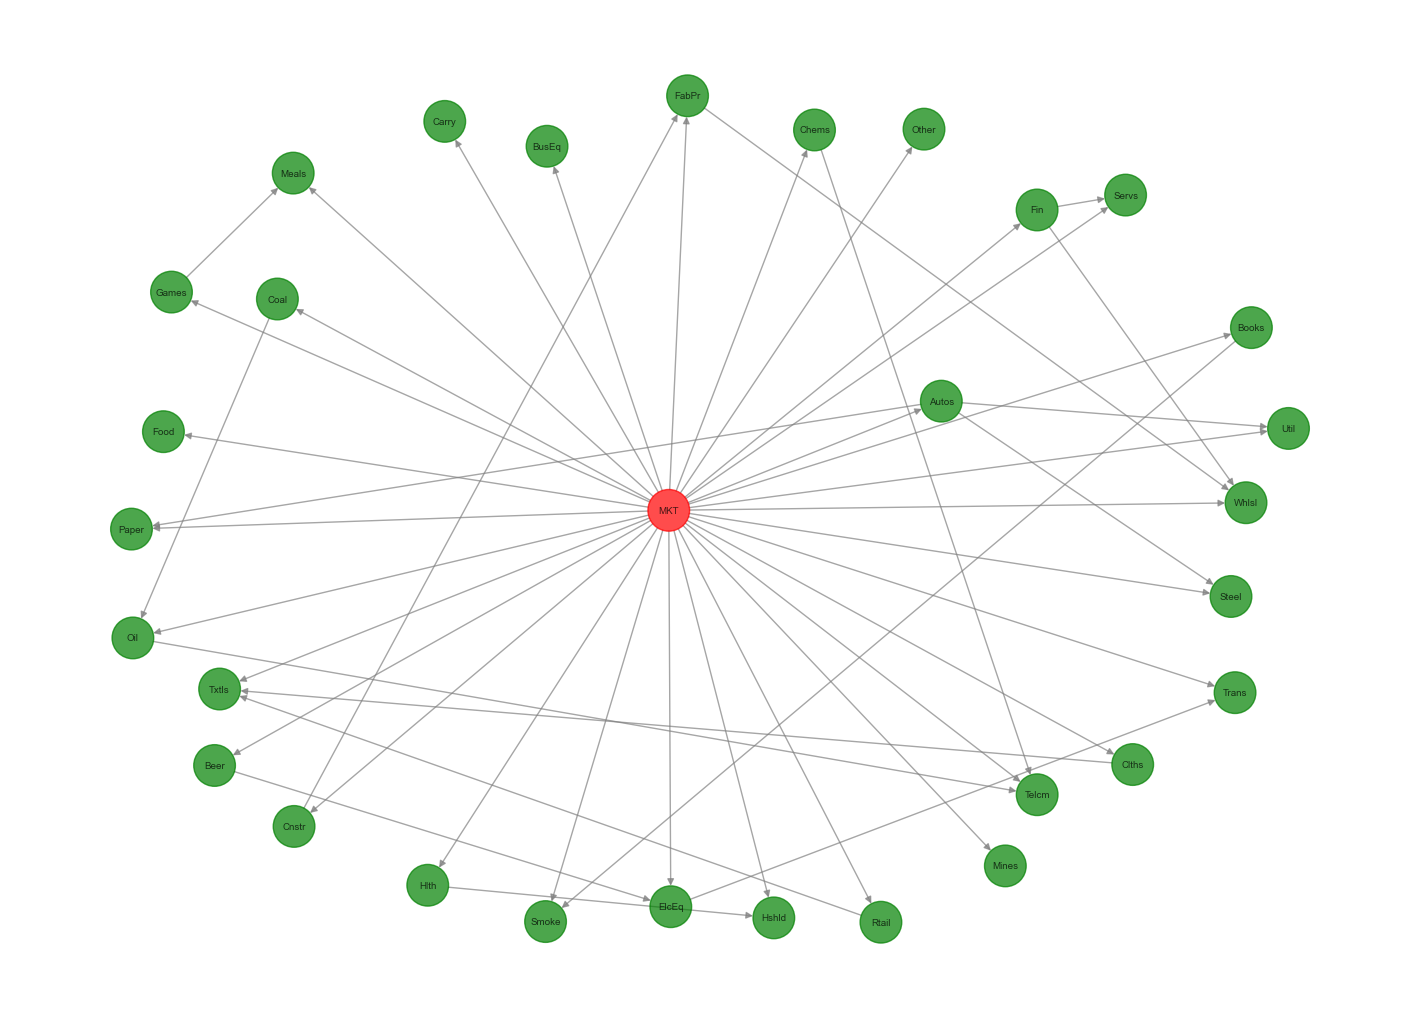

In [56]:
# Directed graph
visualize_bn(dag_edges)

#### 4.2.3. Markov Network

In [58]:
# Prepare X (assets only), split, standardize (reuse existing functions)
X = industry_df.values
assets_mrf = list(industry_df.columns)

X_train, X_test = time_split(X, train_ratio=0.7)
Xtr, Xte, scaler = standardize_train_test(X_train, X_test)

# Structure learning (CV by default; reuse existing function)
gl_model = fit_graphical_lasso_cv(Xtr)
precision = gl_model.precision_
covariance = gl_model.covariance_

G = precision_to_graph(precision, assets_mrf)

# Sector mapping is not available here; we provide a placeholder mapping (metric not economically meaningful)
asset_to_sector_dummy = {a: a for a in assets_mrf}
mrf_stats = graph_stats(G, asset_to_sector_dummy)

test_metrics = evaluate_on_test(gl_model, Xte)

print("\n=== 30 Industry — MRF/GGM Graph Stats ===")
print(mrf_stats)
print("\n=== 30 Industry — MRF/GGM Test Metrics ===")
print(test_metrics)

# Example: predict one target industry from a small observed set
target_asset = assets_mrf[0]
observed_assets = assets_mrf[1:6]

inference_result = evaluate_conditional_inference_on_test(
    covariance_std=covariance,
    X_test_std=Xte,
    X_test_raw=X_test,
    assets=assets_mrf,
    scaler=scaler,
    target_asset=target_asset,
    observed_assets=observed_assets
)

print("\n=== 30 Industry — Conditional inference (MRF/GGM) ===")
print({k: inference_result[k] for k in ["target", "observed", "mse", "corr"]})

C:\Users\Manuel\anaconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:167: RuntimeWarning: invalid value encountered in multiply
  precision_[indices != idx, idx] = -precision_[idx, idx] * coefs
C:\Users\Manuel\anaconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:168: RuntimeWarning: invalid value encountered in multiply
  precision_[idx, indices != idx] = -precision_[idx, idx] * coefs
C:\Users\Manuel\anaconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:167: RuntimeWarning: invalid value encountered in multiply
  precision_[indices != idx, idx] = -precision_[idx, idx] * coefs
C:\Users\Manuel\anaconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:168: RuntimeWarning: invalid value encountered in multiply
  precision_[idx, indices != idx] = -precision_[idx, idx] * coefs
C:\Users\Manuel\anaconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:167: RuntimeWarning: invalid value encountered in multiply
  precision_[indices != idx, idx] = -precision


=== 30 Industry — MRF/GGM Graph Stats ===
{'n_nodes': 30, 'n_edges': 223, 'density': 0.5126436781609195, 'sparsity': 0.4873563218390805, 'n_components': 1, 'component_sizes_desc': [30], 'within_sector_edge_ratio': 0.0}

=== 30 Industry — MRF/GGM Test Metrics ===
{'avg_loglik': -5067.272514618786, 'total_loglik': -7256334.240934101}

=== 30 Industry — Conditional inference (MRF/GGM) ===
{'target': 'Food', 'observed': ['Beer', 'Smoke', 'Games', 'Books', 'Hshld'], 'mse': 228.79869909319112, 'corr': 0.9743578948120745}


C:\Users\Manuel\AppData\Local\Temp\ipykernel_12032\3270775412.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


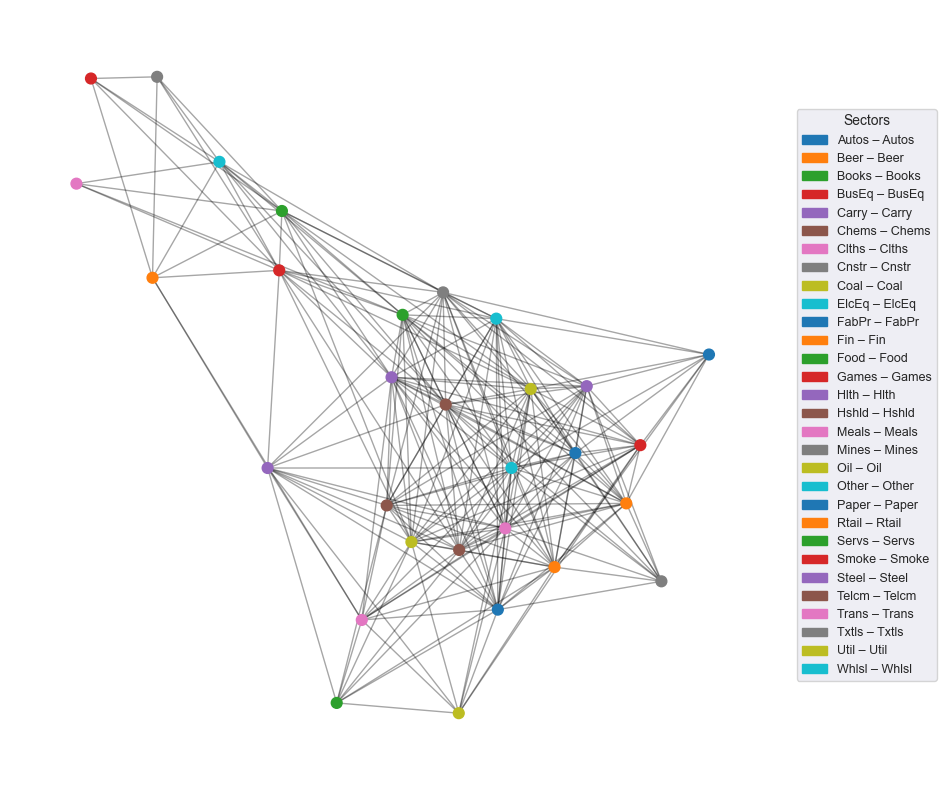

In [59]:
# Each asset is treated as its own "sector"
asset_to_sector_30ind = {a: a for a in assets_mrf}

plot_network(
    G,
    asset_to_sector_30ind,
    max_nodes=100,
    seed=42
)